In [114]:
from micrograd.engine import Value

In [138]:
import math
class Value:
    def __init__(self,data,_children=(),_op='',label='',grad=0):
        self.data=data
        self.grad=grad
        self._prev=set(_children)
        self._op=_op
        self.backward=lambda :None
        self.label=label
    def __repr__(self):
        return "data= {}".format(self.data)
    def __add__(self,other):
        if isinstance(other,Value)==False:
            other=Value(other)
        out=Value(self.data+other.data,(self,other),'+')
        def add_backward():
            self.grad+=out.grad
            other.grad+=out.grad
        out.backward=add_backward
        return out
    def __pow__(self,n):
        assert isinstance(n,(int,float))
        out=Value(self.data**n,(self,),'*')
        def pow_backward():
            self.grad+=n*self.data**(n-1)*out.grad
        out.backward=pow_backward
        return out 
    def __mul__(self,other):
        if isinstance(other,Value)==False:
            other=Value(other)
        out=Value(self.data*other.data,(self,other),'*')
        def mul_backward():
            self.grad+=out.grad*other.data
            other.grad+=out.grad*self.data
        out.backward=mul_backward
        return out
    def tanh(self):
        x=self.data
        t=(math.exp(2*x)-1)/(math.exp(2*x)+1)
        out=Value(t,(self,),'tanh',label="out")
        def tanh_backward():
            self.grad+=(1-t**2)*out.grad
        out.backward=tanh_backward
        return out
    
    def back_ward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1
        for v in reversed(topo):
            v.backward()
    def __neg__(self):
        return self * -1
    def __radd__(self, other):
        return self + other
    def __sub__(self, other):
        return self + (-other)
    def __rsub__(self, other):
        return other + (-self)
    def __rmul__(self, other):
        return self * other
    def __truediv__(self, other): 
        return self * other**-1
    def __rtruediv__(self, other): 
        return other * self**-1

In [116]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))

        dot.node(name = uid, label = "{ %s | data %.6f| grad %.6f }" % (n.label, n.data,n.grad), shape='record')
        if n._op:
            dot.node(name = uid + n._op, label = n._op)
           
            dot.edge(uid + n._op, uid)
            
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
        
    return dot

In [117]:
import random
class Neuron:
    def __init__(self,n):
        self.w=[Value(random.uniform(-1,1)) for i in range (n)]
        self.b=Value(random.uniform (-1,1))
    def __call__(self,x):
        L=[]
        for i in range (len(x)):
            L.append((self.w[i],x[i]))
        act=sum([xi*wi for xi,wi in L],self.b)
        return act.tanh()
    def parameters(self):
        return self.w+[self.b] 
class Layer:
    def __init__(self,nin,nn):
        self.neurons=[Neuron(nin) for i in range(nn)]
    def __call__(self,x):
            outs=[n(x) for n in self.neurons]
            return(outs)
    def parameters(self):
        out=[]
        for n in self.neurons:
            out+=n.parameters()
        return(out)
class MLP:
    def __init__(self,nin,nouts):
        sz=[nin]+nouts
        self.layers=[Layer(sz[i],sz[i+1]) for i in range (len(sz)-1)]
    def __call__(self,x):
        for layer in self.layers:
            x=layer(x)
        if len (x)==1:
            return x[0]
        else:
            return x 
    def parameters(self):
        out=[]
        for l in self.layers:
            out+=l.parameters()
        return(out)

In [118]:
n=MLP(3,[3,4,4,1])
xs=[[2,3,-1],
    [3,-1,0.5],
    [0.5,1,1],
    [1,1,-1],
   ]
ys=[1,-1,-1,1]

In [136]:
for i in range(500):
    ypred=[n(x) for x in xs]
    _loss=[]
    for i in range (len(ys)):
        _loss.append(((-ys[i])+ypred[i])**2)
    loss=sum(_loss)
    for p in n.parameters():
        p.grad=0
    loss.back_ward()
    for p in n.parameters():
        p.data+=-0.05*p.grad
print(loss.data)

6.820895720745115e-05


In [137]:
n([2,3,-1])

data= 0.9965058558874916

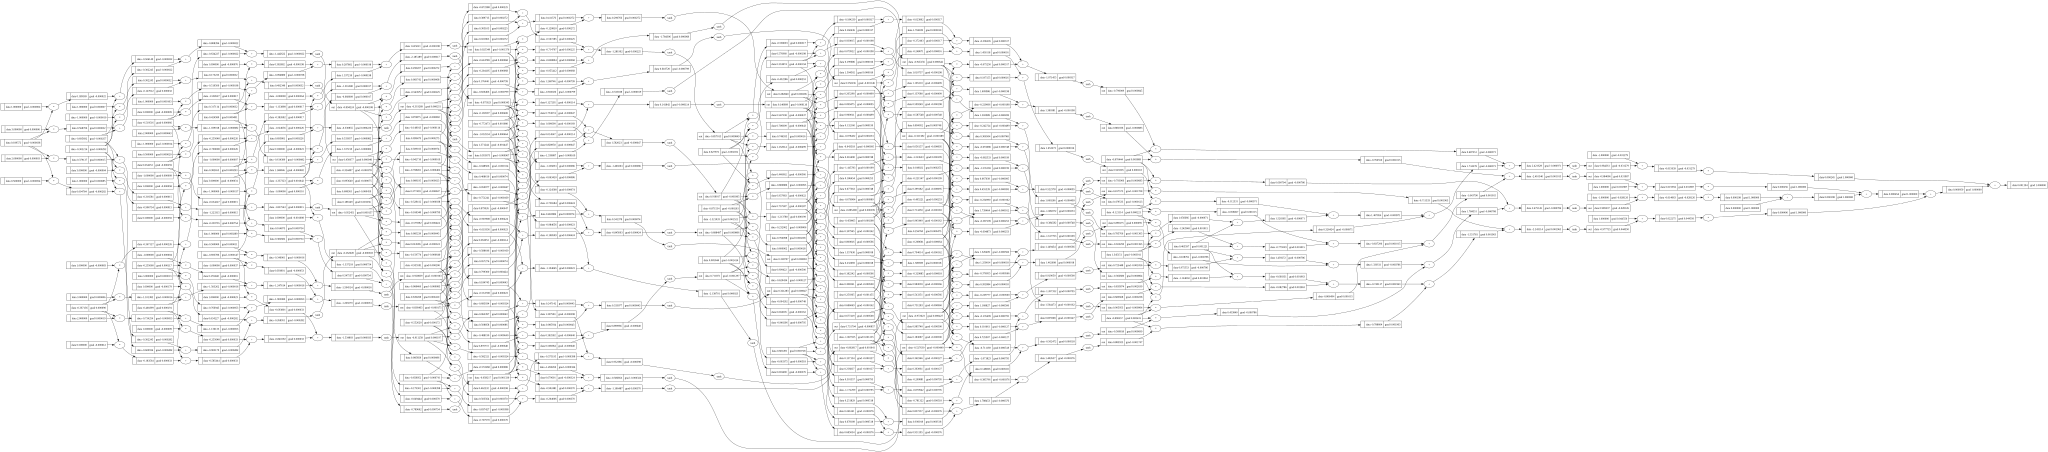

In [121]:
draw_dot(loss)